In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

c:\Users\Raghunandan\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.read_csv('Employee.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

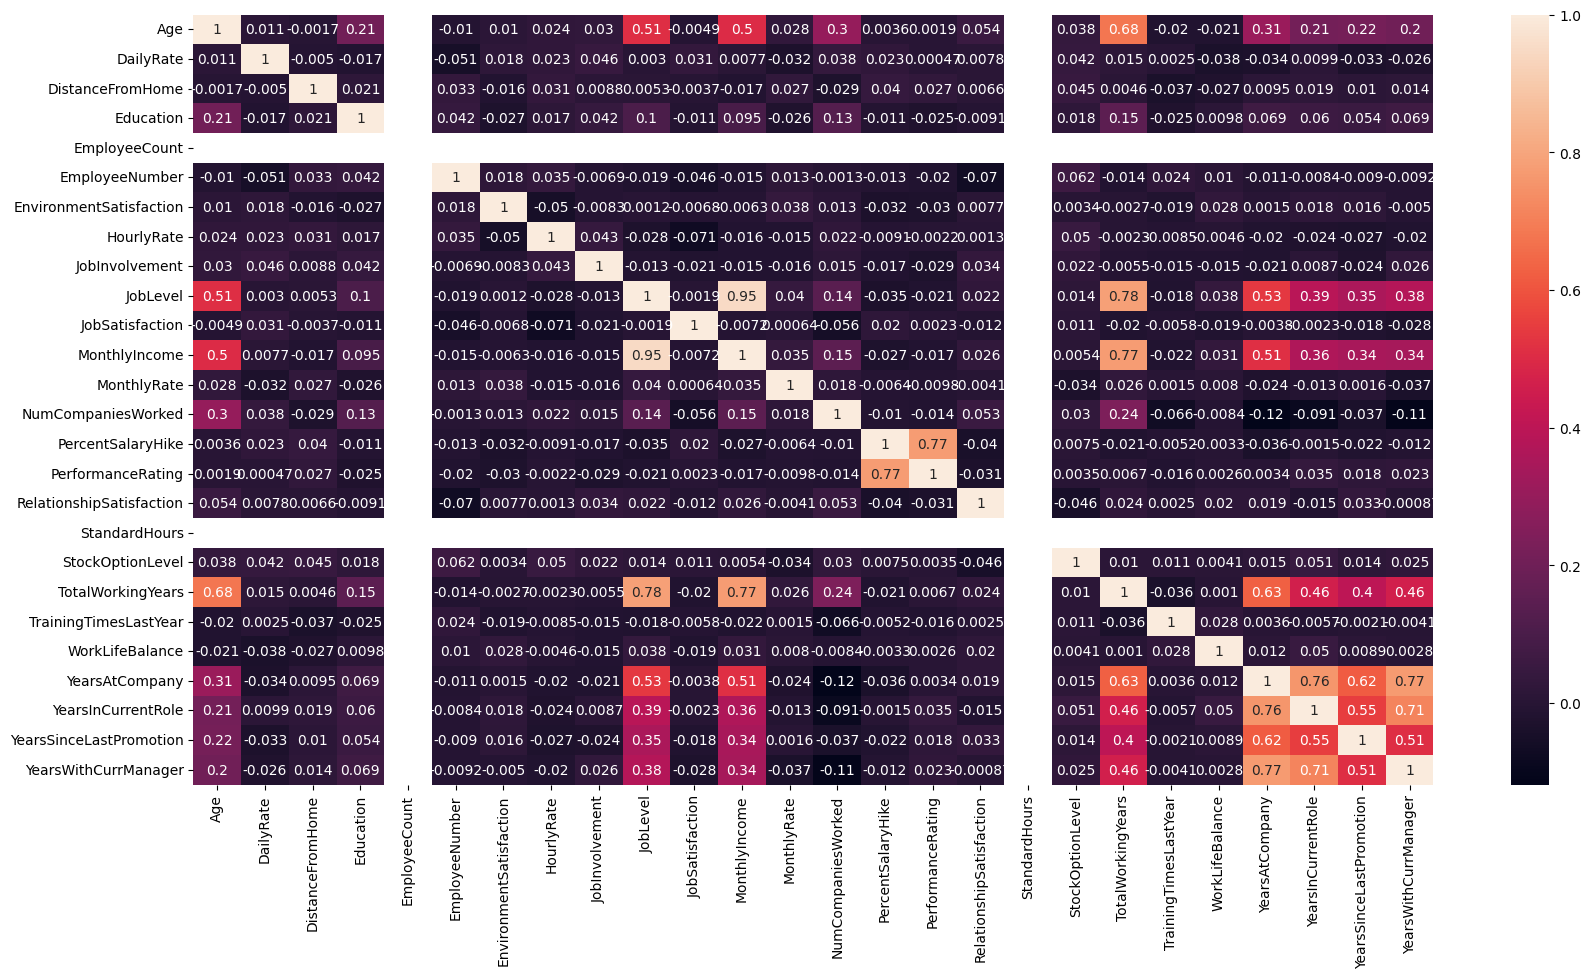

In [6]:
corr=df.select_dtypes(include='number').corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr,annot=True)
plt.show()

In [49]:
# Select the features and target variable
x=df[['Age','DistanceFromHome','MonthlyIncome','NumCompaniesWorked']]
y=df['Attrition'].map({'Yes':1,'No':0})
print(x,y)

      Age  DistanceFromHome  MonthlyIncome  NumCompaniesWorked
0      41                 1           5993                   8
1      49                 8           5130                   1
2      37                 2           2090                   6
3      33                 3           2909                   1
4      27                 2           3468                   9
...   ...               ...            ...                 ...
1465   36                23           2571                   4
1466   39                 6           9991                   4
1467   27                 4           6142                   1
1468   49                 2           5390                   2
1469   34                 8           4404                   2

[1470 rows x 4 columns] 0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64


In [50]:
# Split the train and test data
from sklearn.model_selection import train_test_split

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

In [53]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [55]:
model=Sequential([
    Dense(16,activation='relu',input_shape=(x_train.shape[1],)),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [56]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [57]:
# Train the model
history=model.fit(x_train,y_train,epochs=20,validation_split=0.2,batch_size=32) # Use 20% of data for validation

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8394 - loss: 0.5241 - val_accuracy: 0.7966 - val_loss: 0.5301
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8404 - loss: 0.4781 - val_accuracy: 0.7966 - val_loss: 0.5087
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8404 - loss: 0.4542 - val_accuracy: 0.7966 - val_loss: 0.5010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8404 - loss: 0.4435 - val_accuracy: 0.7966 - val_loss: 0.4949
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8404 - loss: 0.4385 - val_accuracy: 0.7966 - val_loss: 0.4928
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8404 - loss: 0.4340 - val_accuracy: 0.7966 - val_loss: 0.4882
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8404 - loss: 0.4310 - val_accuracy: 0.7966 - val_loss: 0.4851
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8404 - loss: 0.4279 - val_accuracy: 0.7966 - val_loss:

In [60]:
# Model Evaluation
loss,acc=model.evaluate(x_test,y_test)
print(f"Loss value : {loss}")
print(f"Accuracy : {acc}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8673 - loss: 0.3695 
Loss value : 0.3695319592952728
Accuracy : 0.8673469424247742


In [61]:
# Predictions
pred=model.predict(x_test)

# Convert probabilities into predictions
pred=(pred>0.5)
print(pred[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]
